In [1]:
!pip install numpy matplotlib

P(X = 3) simulada = 0.103130
P(T > 6) simulada = 0.116070
Media simulada = 2.3221
Variancia simulada = 7.6661


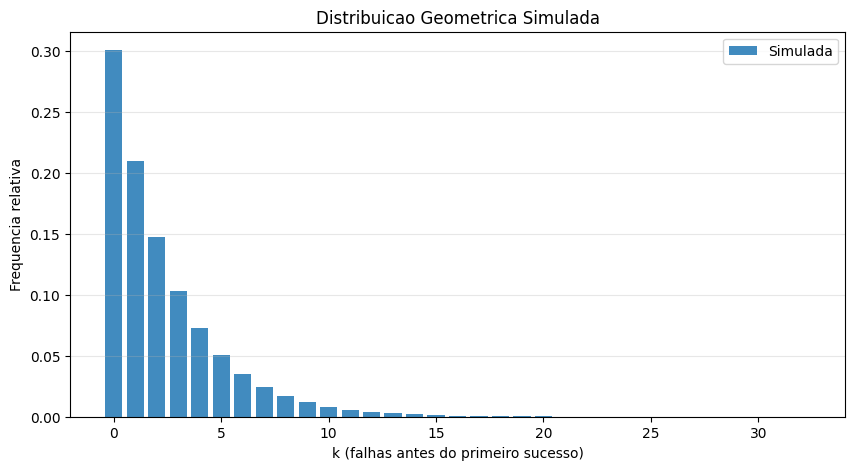

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parametros da distribuicao geometrica
p = 0.3
N = 100000
value = 3  # X = numero de falhas antes do primeiro sucesso

np.random.seed(42)

# Simulacao por inversao da CDF
av = np.array([], dtype=int)
x = np.random.uniform(0, 1, N)
for ix in x:
    i = 0
    pr = p
    F = pr
    while ix >= F:
        i = i + 1
        pr = (1 - p) * pr
        F = F + pr
    av = np.append(av, i)

pb_sim = np.mean(av == value)  # P(X = 3)
pc_sim = np.mean(av >= 6)      # P(T > 6)
media_sim = np.mean(av)
var_sim = np.var(av)

print(f'P(X = 3) simulada = {pb_sim:.6f}')
print(f'P(T > 6) simulada = {pc_sim:.6f}')
print(f'Media simulada = {media_sim:.4f}')
print(f'Variancia simulada = {var_sim:.4f}')

k, counts = np.unique(av, return_counts=True)
freq_simulada = counts / N

plt.figure(figsize=(10, 5))
plt.bar(k, freq_simulada, width=0.8, label='Simulada', alpha=0.85)
plt.xlabel('k (falhas antes do primeiro sucesso)')
plt.ylabel('Frequencia relativa')
plt.title('Distribuicao Geometrica Simulada')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.show()